# 01. Data Protection Strategies

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply data protection principles to AI workflows
- Identify and minimize privacy risks
- Handle sensitive data responsibly

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 2, lesson 01 "Data Loading" — every column you load is a claim on somebody's information.

**Used later in:** Course 11 (AIAT 125) — Unit 3, lesson 05 "Securing ML Model APIs" — the same duties, enforced on a live endpoint.

---


# 01. Data Protection Strategies

## 🚨 THE PROBLEM: AI Systems Collect and Process Personal Data

**Remember the transition from Unit 2?**

We completed Unit 2: Bias and Justice, where we learned:
- How to detect and mitigate bias
- How to ensure fair representation
- How to build fair AI systems

**But there's a new challenge:**

**AI systems also raise privacy and security concerns!**

**The Problem**: As we build AI systems, we need to consider:
- ❌ **Privacy**: How do we protect user data?
- ❌ **Security**: How do we secure AI systems?
- ❌ **Data Protection**: How do we prevent unauthorized access?
- ❌ **Compliance**: How do we meet privacy regulations?

**We've learned:**
- ✅ How to build fair AI systems (Unit 2)
- ✅ How to detect and mitigate bias
- ✅ How to ensure ethical AI development

**But we haven't learned:**
- ❌ How to **protect** personal data in AI systems
- ❌ How to **encrypt** sensitive information
- ❌ How to **anonymize** data for privacy
- ❌ How to **secure** data storage and processing

**We need data protection strategies** to:
1. Encrypt sensitive data
2. Anonymize personal information
3. Secure data storage and transmission
4. Protect user privacy

**This notebook solves that problem** by teaching you data protection strategies like encryption, anonymization, and secure storage!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Unit 1: Ethics Foundations** - Understanding ethical principles
- ✅ **Unit 2: Bias and Justice** - Understanding fairness in AI
- ✅ **Basic Python knowledge**: Functions, data manipulation, dictionaries
- ✅ **Understanding of data privacy**: Basic concepts of privacy and security

**If you haven't completed these**, you might struggle with:
- Understanding why data protection matters
- Knowing which protection technique to use
- Understanding encryption and anonymization concepts

---

## 🔗 Where This Notebook Fits

**This is the FIRST example in Unit 3** - it teaches you how to protect data!

**Why this example FIRST?**
- **Before** you can use privacy technologies, you need to understand basic protection
- **Before** you can implement differential privacy, you need data protection basics
- **Before** you can ensure GDPR compliance, you need protection strategies

**Builds on**: 
- 📓 Unit 1: Ethics Foundations (ethical principles)
- 📓 Unit 2: Bias and Justice (fairness concepts)

**Leads to**: 
- 📓 Example 2: Privacy Technologies (advanced privacy techniques)
- 📓 Example 3: Differential Privacy (mathematical privacy guarantees)
- 📓 Example 4: GDPR Compliance (regulatory compliance)
- 📓 Example 5: Secure Development (secure coding practices)

**Why this order?**
1. Data protection provides **foundation** (needed before advanced techniques)
2. Data protection teaches **basic techniques** (encryption, anonymization)
3. Data protection shows **practical approaches** (real-world strategies)

---

## The Story: Protecting What Matters

Imagine you're a bank protecting customer money. **Before** you can offer services, you need vaults, locks, security systems. **After** implementing protection, customer assets are secure!

Same with data: **Before** we have sensitive data that needs protection, now we learn techniques - encryption, anonymization, pseudonymization. **After** data protection, we have secure data that can't be misused!

---

## Why Data Protection Matters

Data protection is essential for ethical AI:
- **Privacy**: Protect individuals' personal information
- **Security**: Prevent unauthorized access to data
- **Compliance**: Meet legal and regulatory requirements
- **Trust**: Build user confidence in your systems
- **Ethics**: Respect individuals' right to privacy

## Learning Objectives
1. Understand encryption techniques for data protection
2. Learn secure data storage practices
3. Understand anonymization and pseudonymization
4. Compare different data protection strategies
5. Apply protection techniques to real data
6. Understand when to use each technique

## 📌 The case: AOL deleted the names and published the people anyway

**August 2006.** AOL, meaning to help researchers, published three months of search logs:
about **20 million queries from roughly 650,000 users**. It did the obvious protection
first — every username was replaced by a number. The data was, in the language of the press
release, anonymised.

On **9 August 2006** the *New York Times* ran a front-page article identifying **user
#4417749** as **Thelma Arnold**, a 62-year-old widow in Lilburn, Georgia, from her queries
alone. Reporters did it by reading. AOL withdrew the file within days; it had already been
mirrored, and remains online today. Nothing can be un-published.

**Why deleting identifiers is not anonymisation.** Latanya Sweeney had already proved the
general result: **87 % of the US population is uniquely identified by just ZIP code, date of
birth and sex**. She demonstrated it by buying Massachusetts voter records for $20, linking
them to a "de-identified" state hospital release, and pulling out the medical record of the
sitting governor, William Weld.

You are about to reproduce that result on real people. Of the **891 Titanic passengers**,
after their names are deleted, you will measure how many are still unique on four ordinary
fields — sex, class, port and age. The answer this run gives is **224 people, one in four**.

**The WHY — what goes wrong without data protection.** Every organisation you will work for
holds a table it thinks is anonymous, and someone will eventually ask to share it. Without
the measurement in this notebook, "we removed the names" sounds like a complete answer.
With it, you can say what fraction of your file is still singled out and by which columns —
which is the difference between a data-sharing agreement and a data breach with a press
release attached.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- The **real Titanic passenger manifest** (`load("titanic")`,
  891 real people). It carries genuine direct identifiers - full names with
  titles, ticket numbers, cabin numbers - and genuine quasi-identifiers
  (sex, class, port of embarkation, age), which is exactly what a privacy
  engineer has to protect in practice.
- `cryptography.fernet` for encryption, `hashlib` for hashing/pseudonyms.

**Outputs:** What you'll see when you run the cells

- A real passenger record encrypted and decrypted round-trip.
- The same real records anonymized and pseudonymized side by side.
- A measured re-identification risk: how many of the 891 passengers are still
  unique once their names are deleted.

---


In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - datasets are loaded by NAME, never by file path.")


Data loader ready - datasets are loaded by NAME, never by file path.


In [2]:
# Step 1: Import necessary libraries
# These libraries help us implement data protection strategies

import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, comparisons
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
from cryptography.fernet import Fernet  # For encryption: Symmetric encryption (Fernet)
import hashlib  # For hashing: Create hash-based pseudonyms
import warnings  # For suppressing warnings: Clean output
import os  # For file operations: Saving images

# Suppress warnings: Clean output
warnings.filterwarnings('ignore')  # Ignore warnings: Suppress non-critical warnings

# Configure plotting: Set default styles for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)
sns.set_style("whitegrid")  # Style: White background with grid for clean look

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - numpy/pandas: Data manipulation and numerical operations")
print("   - matplotlib/seaborn: Create visualizations (charts, heatmaps)")
print("   - cryptography.fernet: Encryption (symmetric encryption)")
print("   - hashlib: Hashing (create pseudonyms)")
print("   - os: File operations (saving images)")


✅ Libraries imported successfully!

📚 What each library does:
   - numpy/pandas: Data manipulation and numerical operations
   - matplotlib/seaborn: Create visualizations (charts, heatmaps)
   - cryptography.fernet: Encryption (symmetric encryption)
   - hashlib: Hashing (create pseudonyms)
   - os: File operations (saving images)


## Part 2: Encryption Techniques

### 📚 Prerequisites (What You Need First)
- ✅ **Library imports** (from Part 1) - Understanding encryption tools
- ✅ **Understanding of security** - Basic concepts of data security

### 🔗 Relationship: What This Builds On
This is the first data protection technique - encryption!
- Builds on: Understanding of data security, cryptography basics
- Shows: How to encrypt data to prevent unauthorized access

### 📖 The Story
**Before encryption**: We have sensitive data that anyone can read.
**After encryption**: We have encrypted data that only authorized parties can decrypt!

---

## Step 2: Encryption Techniques

**BEFORE**: We have sensitive data in plain text that anyone can read.

**AFTER**: We'll encrypt data so only authorized parties with the key can decrypt it!

**Why encryption?** Protects data at rest and in transit:
- **Confidentiality**: Only authorized parties can read data
- **Integrity**: Detects if data has been tampered with
- **Authentication**: Verifies data source

In [3]:
# Step 2: Implement encryption techniques
# This shows how to encrypt and decrypt data using symmetric encryption

# BEFORE: We have sensitive data in plain text
# AFTER: We'll encrypt data so only authorized parties can read it

print("\n" + "="*80)
print("🔐 ENCRYPTION TECHNIQUES")
print("="*80)
print("\nWe'll implement:")
print("  1. Generate encryption key")
print("  2. Encrypt sensitive data")
print("  3. Decrypt data with the key\n")

def generate_encryption_key():
    """
    Generate a symmetric encryption key.
    
    HOW IT WORKS:
    1. Uses Fernet (symmetric encryption) to generate a key
    2. Key is a URL-safe base64-encoded 32-byte key
    3. Same key is used for encryption and decryption
    
    ⏰ WHEN to use: Before encrypting data - need a key first
    💡 WHY use: Symmetric encryption is fast and secure for data protection
    """
    return Fernet.generate_key()  # Generate key: Create new encryption key

def encrypt_data(data, key):
    """
    Encrypt data using Fernet symmetric encryption.
    
    HOW IT WORKS:
    1. Creates Fernet cipher with the key
    2. Converts data to bytes (if string)
    3. Encrypts the data using the cipher
    4. Returns encrypted bytes
    
    ⏰ WHEN to use: To protect sensitive data from unauthorized access
    💡 WHY use: Encryption ensures only authorized parties can read data
    """
    f = Fernet(key)  # Create cipher: Initialize Fernet with encryption key
    if isinstance(data, str):  # Check type: If data is a string
        encrypted = f.encrypt(data.encode())  # Encrypt: Convert to bytes and encrypt
    else:  # Otherwise: If data is not a string
        encrypted = f.encrypt(str(data).encode())  # Encrypt: Convert to string, then bytes, then encrypt
    return encrypted  # Return: Encrypted data as bytes

def decrypt_data(encrypted_data, key):
    """
    Decrypt data using Fernet symmetric encryption.
    
    HOW IT WORKS:
    1. Creates Fernet cipher with the key
    2. Decrypts the encrypted data
    3. Converts bytes back to string
    4. Returns decrypted string
    
    ⏰ WHEN to use: To read encrypted data (need the same key used for encryption)
    💡 WHY use: Allows authorized parties to access protected data
    """
    f = Fernet(key)  # Create cipher: Initialize Fernet with decryption key
    decrypted = f.decrypt(encrypted_data)  # Decrypt: Decrypt the encrypted data
    return decrypted.decode()  # Return: Decrypted data as string

# Demonstrate encryption on a REAL personal record
# WHY real data: everything encrypted below is a genuine identifier from the
# Titanic passenger manifest - a real full name (with title), a real ticket
# number, a real cabin. Invented records are tidy and uniform; real ones carry
# punctuation, titles and missing values, and your protection code must survive
# all three.
titanic = load("titanic")  # Load: real manifest, 891 passengers, by name not by path
print(f"\nLoaded the REAL Titanic manifest: {len(titanic)} passengers, "
      f"{titanic.shape[1]} columns")

person = titanic.iloc[0]  # Pick one real passenger record to protect
original_data = (f"PassengerId={person['PassengerId']}; Name={person['Name']}; "
                 f"Age={person['Age']}; Ticket={person['Ticket']}; "
                 f"Cabin={person['Cabin']}")  # Build: the plaintext record we must protect

print("\nDemonstrating encryption on that record...")
key = generate_encryption_key()  # Generate key: create the encryption key
encrypted = encrypt_data(original_data, key)  # Encrypt: protect the record
decrypted = decrypt_data(encrypted, key)  # Decrypt: recover it with the same key

print(f"Original : {original_data}")  # Print: the identifiable plaintext
print(f"Encrypted: {encrypted[:80]}...")  # Print: ciphertext (truncated for readability)
print(f"Decrypted: {decrypted}")  # Print: recovered plaintext
print(f"Round-trip identical: {decrypted == original_data}")  # Check: lossless

# Real data teaches something a made-up record cannot: the gaps are real too.
n_missing_cabin = int(titanic['Cabin'].isna().sum())
print(f"\nNotice 'Cabin=nan' in the record above: this passenger's cabin is")
print(f"genuinely absent from the manifest - {n_missing_cabin} of {len(titanic)} cabins are missing.")
print("Encryption protects whatever you hand it, gaps included. It hides data;")
print("it does not clean it, and it does not make the data any less personal.")
print("\u2705 Encryption demonstration complete!")



🔐 ENCRYPTION TECHNIQUES

We'll implement:
  1. Generate encryption key
  2. Encrypt sensitive data
  3. Decrypt data with the key

titanic: full file, 891 rows.

Loaded the REAL Titanic manifest: 891 passengers, 12 columns

Demonstrating encryption on that record...
Original : PassengerId=1; Name=Braund, Mr. Owen Harris; Age=22.0; Ticket=A/5 21171; Cabin=nan
Encrypted: b'gAAAAABqlLjYe_rlYzK61q86DlFY-rOksHGuSmSJ-_Spjy1NfsI28Gf-rPkKR091hgYaML1HDdZg5EFh'...
Decrypted: PassengerId=1; Name=Braund, Mr. Owen Harris; Age=22.0; Ticket=A/5 21171; Cabin=nan
Round-trip identical: True

Notice 'Cabin=nan' in the record above: this passenger's cabin is
genuinely absent from the manifest - 687 of 891 cabins are missing.
Encryption protects whatever you hand it, gaps included. It hides data;
it does not clean it, and it does not make the data any less personal.
✅ Encryption demonstration complete!


## Part 3: Anonymization and Pseudonymization Techniques

### 📖 The Story
**Before**: our records still contain real names, ticket numbers and precise
attributes that identify real people.
**After**: we can **anonymize** (irreversibly remove/generalize identifiers) and
**pseudonymize** (replace identifiers with tokens reversible only with the salt)
those same real records - and then *measure* whether the result is really anonymous.

| Technique | Reversible? | GDPR view |
|---|---|---|
| Anonymization | No | Properly anonymized data is no longer "personal data" |
| Pseudonymization | Yes (with the key/salt table) | Still personal data - but safer |

The measurement at the end is the part a toy table can never show you: deleting
names does **not** make a real dataset anonymous.


In [4]:
# WHY: protecting the same REAL table two ways shows the key difference -
# anonymization destroys the link to the person, pseudonymization only hides it -
# and then we MEASURE whether "anonymized" really means anonymous.

# Step 3: Anonymize and pseudonymize real passenger records

print("\n" + "="*80)
print("\U0001F575\uFE0F ANONYMIZATION AND PSEUDONYMIZATION (real Titanic manifest)")
print("="*80)

# Direct identifiers name a person outright: Name, Ticket, Cabin.
# Quasi-identifiers are harmless alone but identifying in combination:
# Sex, Pclass, Embarked, Age. Both kinds are real columns of this file.
sample = titanic.sample(8, random_state=42)[
    ['Name', 'Sex', 'Age', 'Pclass', 'Embarked', 'Ticket', 'Cabin', 'Survived']]
print("\nORIGINAL records - 8 real passengers, sampled with random_state=42:")
print(sample.to_string(index=False))

# --- Anonymization: drop direct identifiers, generalize quasi-identifiers ---
AGE_BINS = [0, 18, 30, 45, 120]  # Age bands: coarser values put more people in each group
AGE_LABELS = ['<=18', '19-30', '31-45', '46+']
anonymized = sample.drop(columns=['Name', 'Ticket', 'Cabin']).copy()  # Drop: the direct identifiers
anonymized['Age'] = pd.cut(anonymized['Age'], bins=AGE_BINS, labels=AGE_LABELS)  # Generalize: exact age -> band
print("\nANONYMIZED (direct identifiers dropped, age generalized to bands):")
print(anonymized.to_string(index=False))
print("-> Irreversible: no name, no ticket, no cabin is left to map back.")

# Real data leaves real holes: some of these passengers have no recorded age,
# so their band is NaN. Generalization cannot invent a value it never had.
n_no_age = int(sample['Age'].isna().sum())
n_no_cabin = int(sample['Cabin'].isna().sum())
print(f"   ({n_no_age} of the 8 sampled passengers have no recorded age and "
      f"{n_no_cabin} no cabin -")
print("    real gaps, carried straight through the protection step.)")

# --- But is it anonymous? Measure re-identification risk on ALL 891 rows ---
# Why the full table: uniqueness is a property of the whole dataset, not of an
# 8-row excerpt. This is the number an auditor would ask you for.
QI = ['Sex', 'Pclass', 'Embarked', 'Age']
unique_exact = int((~titanic.duplicated(subset=QI, keep=False)).sum())  # Count: rows with no twin

banded = titanic.copy()
banded['Age'] = pd.cut(banded['Age'], bins=AGE_BINS, labels=AGE_LABELS)  # Same generalization, whole table
unique_banded = int((~banded.duplicated(subset=QI, keep=False)).sum())

n = len(titanic)
print(f"\nRE-IDENTIFICATION CHECK on all {n} passengers (names already deleted):")
print(f"  unique on {QI} with exact age : {unique_exact} people "
      f"({unique_exact/n:.1%})")
print(f"  unique on the same four fields with age in 4 bands: {unique_banded} people "
      f"({unique_banded/n:.1%})")
print("\n-> Deleting the names was NOT anonymization. With an exact age, one in")
print("   four of these passengers is singled out by four ordinary attributes.")
print("   Generalizing age collapses most of that risk, but not all of it - the")
print("   remaining unique rows still have to be suppressed (Notebook 07).")

# --- Pseudonymization: replace the identifier with a salted-hash token ---
SALT = 'course06-demo-salt'  # In production: a secret, stored separately from the data
def pseudonym(value, salt=SALT):
    """Stable token for one identifier: same input + same salt -> same token."""
    return hashlib.sha256((salt + str(value)).encode()).hexdigest()[:12]

pseudonymized = sample.copy()
pseudonymized['passenger_token'] = pseudonymized['Name'].apply(pseudonym)  # Tokenize: name -> hash
pseudonymized = pseudonymized.drop(columns=['Name', 'Ticket', 'Cabin'])
pseudonymized = pseudonymized[['passenger_token', 'Sex', 'Age', 'Pclass',
                               'Embarked', 'Survived']]
print("\nPSEUDONYMIZED (real names replaced by stable tokens):")
print(pseudonymized.to_string(index=False))

# The weakness, demonstrated rather than asserted: anyone who knows a passenger's
# exact name and holds the salt can recompute the token and find their row.
target_name = sample.iloc[0]['Name']
target_token = pseudonym(target_name)
hit = pseudonymized[pseudonymized['passenger_token'] == target_token]
print(f"\nLinkage attack: hash the known name '{target_name}' with the same salt")
print(f"-> token {target_token}, which matches {len(hit)} row(s):")
print(hit.to_string(index=False))
print("\n-> The SAME person always gets the SAME token, so records stay linkable")
print("   across tables. That is useful - and it is exactly why GDPR treats")
print("   pseudonymized data as STILL personal data.")



🕵️ ANONYMIZATION AND PSEUDONYMIZATION (real Titanic manifest)

ORIGINAL records - 8 real passengers, sampled with random_state=42:
                                             Name    Sex  Age  Pclass Embarked           Ticket Cabin  Survived
Moubarek, Master. Halim Gonios ("William George")   male  NaN       3        C             2661   NaN         1
           Kvillner, Mr. Johan Henrik Johannesson   male 31.0       2        S       C.A. 18723   NaN         0
                      Alhomaki, Mr. Ilmari Rudolf   male 20.0       3        S SOTON/O2 3101287   NaN         0
                Harper, Miss. Annie Jessie "Nina" female  6.0       2        S           248727   NaN         1
                      Nicola-Yarred, Miss. Jamila female 14.0       3        C             2651   NaN         1
                     Barber, Miss. Ellen "Nellie" female 26.0       1        S            19877   NaN         1
         Kelly, Miss. Anna Katherine "Annie Kate" female  NaN       3        Q      

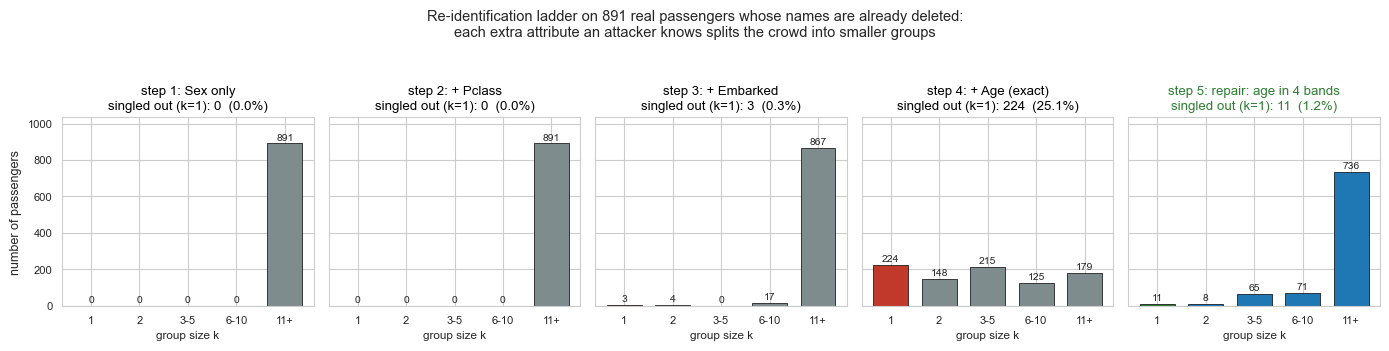


STEP TABLE - passengers left alone in the file at each step:
step  attributes known         singled out (k=1)  share of 891
   1  Sex only                                 0          0.0%
   2  + Pclass                                 0          0.0%
   3  + Embarked                               3          0.3%
   4  + Age (exact)                          224         25.1%
   5  repair: age in 4 bands                  11          1.2%


In [5]:
# WHY a picture here: the two numbers printed above (224 unique, then 11) are the
# whole lesson, but a number does not show WHERE the risk comes from. This
# storyboard adds one quasi-identifier at a time and redraws the crowd, so the
# class can watch anonymity disappear attribute by attribute - and then watch
# generalization put most of it back.

# WHAT k means: k = how many passengers share your exact combination of attributes.
# k = 1 means you are alone in the file: knowing those attributes names you.

BUCKETS = [(1, 1, '1'), (2, 2, '2'), (3, 5, '3-5'), (6, 10, '6-10'), (11, 10**9, '11+')]

def group_sizes(df, cols):
    """k for every row: how many rows share this row's combination of `cols`."""
    # observed=True: count only combinations that actually occur (categorical Age bands)
    # dropna=False: a missing value is itself a value an attacker can match on
    return df.groupby(cols, dropna=False, observed=True)['PassengerId'].transform('size')

# The five steps of the storyboard: four disclosures, then one repair.
steps = [
    (titanic, ['Sex'],                                 'Sex only'),
    (titanic, ['Sex', 'Pclass'],                       '+ Pclass'),
    (titanic, ['Sex', 'Pclass', 'Embarked'],           '+ Embarked'),
    (titanic, QI,                                      '+ Age (exact)'),
    (banded,  QI,                                      'repair: age in 4 bands'),
]

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5), sharey=True)
xs = np.arange(len(BUCKETS))
tick_names = [b[2] for b in BUCKETS]
table_rows = []

for k, (ax, (df, cols, label)) in enumerate(zip(axes, steps)):
    sz = group_sizes(df, cols)                       # k for every passenger at this step
    n_unique = int((sz == 1).sum())                  # how many are alone
    table_rows.append((k + 1, label, n_unique, f"{n_unique / n:.1%}"))
    counts = [int(((sz >= lo) & (sz <= hi)).sum()) for lo, hi, _ in BUCKETS]
    repair = (k == 4)
    body = '#1f77b4' if repair else '#7f8c8d'        # blue = after the fix, grey = before
    head = '#2e7d32' if repair else '#c0392b'        # the k=1 bar: green if fixed, red if not
    # edgecolor: keeps a near-zero bar (e.g. 11 out of 891) visible as a thin line
    bars = ax.bar(xs, counts, color=[head] + [body] * 4, width=0.72,
                  edgecolor='black', linewidth=0.5)
    ax.bar_label(bars, fontsize=7.5, padding=1)
    ax.set_xticks(xs); ax.set_xticklabels(tick_names, fontsize=8)
    ax.set_xlabel('group size k', fontsize=8.5)
    ax.set_title(f"step {k + 1}: {label}\nsingled out (k=1): {n_unique}  ({n_unique / n:.1%})",
                 fontsize=9.5, color=('#2e7d32' if repair else 'black'))
    ax.margins(y=0.16); ax.tick_params(labelsize=8)

axes[0].set_ylabel('number of passengers', fontsize=9)
fig.suptitle('Re-identification ladder on 891 real passengers whose names are already deleted:\n'
             'each extra attribute an attacker knows splits the crowd into smaller groups',
             fontsize=10.5, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.945])
plt.show()

# The same storyboard as a table, so the numbers can be quoted in a report.
print("\nSTEP TABLE - passengers left alone in the file at each step:")
print(f"{'step':>4}  {'attributes known':<24}{'singled out (k=1)':>18}{'share of 891':>14}")
for step, label, n_unique, share in table_rows:
    print(f"{step:>4}  {label:<24}{n_unique:>18}{share:>14}")


**Read the picture.** Each panel is the *same* 891 real passengers, sorted into buckets by
group size *k* — how many people share that passenger's exact combination of attributes. The **leftmost bar** of each panel is *k = 1*: passengers who are alone in the file, and therefore
named by those attributes alone. It is drawn red while the risk stands and green after the repair
in step 5; its exact count is printed above the bar and again in each panel title, because at this
scale 11 out of 891 is only a sliver of ink.

- **Steps 1-2** — sex, then sex *and* class: the k=1 bar is **0**. All 891 people sit in the
  "11+" bucket. Two attributes hide you in a crowd of hundreds.
- **Step 3** — adding port of embarkation: the crowd starts to break up (**3** people alone).
- **Step 4** — adding *exact* age: the tall single bar collapses into a spread, and the red
  k=1 bar jumps to **224 people (25.1 %)** — a quarter of the height of the axis. This is the AOL result reproduced: the names were
  already deleted, and one in four passengers is still singled out.
- **Step 5** — the repair. Nothing was deleted; age was only *generalized* into four bands.
  The k=1 bar falls to **11 (1.2 %)** and **736** passengers move back into groups of 11 or more.

**What it proves:** identifiability is not a property of any one column — it is created by
*combinations*, and the last attribute added (exact age) does almost all of the damage.
It also shows the limit of the fix: 11 real people are still alone in step 5, which is why
generalization has to be followed by suppression (Notebook 07) or noise (Notebook 03).


## 💬 Discuss

Your own run measured, on 891 real people whose names were already deleted:

- unique on `[Sex, Pclass, Embarked, Age]` with **exact** age: **224 people (25.1 %)**
- unique on the same four fields with age in **4 bands**: **11 people (1.2 %)**

1. **Who decides the acceptable residual risk?** Generalising age took you from 25.1 % to
   1.2 % — a huge win — and it is not zero. Eleven real people are still singled out by four
   ordinary attributes. Is 1.2 % acceptable to release publicly? Does your answer change if
   the sensitive column is `Survived` versus a medical diagnosis versus a criminal
   conviction? Name the number you would defend and the reason.
2. **What does the generalisation cost, and who pays?** Every band you widen destroys signal
   a researcher wanted. AOL's file was released *for research*; the Netflix Prize dataset
   (Notebook 07) advanced recommender science before it was de-anonymised. If a hospital
   generalises age into decades and a study consequently misses a real effect in
   80-year-olds, who is harmed and who is protected? Is that trade-off the data
   controller's to make alone?
3. **Pseudonymisation is useful precisely because it is reversible.** Your linkage attack
   hashed a known name with the same salt and pulled that person's row straight back out.
   That is the feature: it keeps records linkable across tables, which is why GDPR still
   treats pseudonymised data as **personal data**. So: in a Saudi hospital operating under
   the PDPL, would you pseudonymise patient records (keeping the salt, keeping the
   liability, keeping the research usable) or anonymise them irreversibly (losing follow-up
   entirely)? Who in the organisation should hold the salt, and what is your plan for the
   day they leave?


---

## 🚫 When Data Protection Hits a Limitation

### The Limitation We Discovered

We've learned basic data protection strategies like encryption, anonymization, and pseudonymization. **But there's still a challenge:**

**What if we need to compute on encrypted data without decrypting it?**

Basic data protection techniques work well when:
- ✅ We can encrypt data at rest
- ✅ We can anonymize data before sharing
- ✅ We can use pseudonymization for reversible protection

**But advanced AI use cases often require:**
- ❌ **Computing on encrypted data** without decryption
- ❌ **Collaborative computation** without sharing raw data
- ❌ **Privacy-preserving machine learning** on sensitive data
- ❌ **Advanced privacy guarantees** beyond basic protection

### Why This Is a Problem

When we need to compute on sensitive data:
- Basic encryption requires decryption before computation
- Anonymization may not provide strong privacy guarantees
- We may need to share data for collaborative AI
- Advanced use cases need advanced privacy technologies

### The Solution: Privacy-Enhancing Technologies (PETs)

We need **advanced privacy-enhancing technologies** to:
1. Compute on encrypted data (homomorphic encryption)
2. Enable secure multi-party computation
3. Provide stronger privacy guarantees
4. Support privacy-preserving machine learning

**This is exactly what we'll learn in the next notebook: Privacy Technologies!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to encrypt sensitive data
- ✅ How to anonymize and pseudonymize data
- ✅ **The limitation**: We need advanced privacy technologies!

**Next notebook**: `02_privacy_technologies.ipynb`
- Learn about homomorphic encryption
- Understand secure multi-party computation
- Explore privacy-preserving machine learning techniques

## ⚠️ Where this breaks

- **Encryption protects data from people who lack the key — not from people who have one.**
  In the 2015 Anthem breach, **78.8 million** health-plan members' records were taken after
  attackers phished credentials from a subsidiary and moved laterally; the US Department of
  Health and Human Services later settled with Anthem for **$16 million**, the largest
  HIPAA settlement to that date. Encryption at rest defeats a stolen disk. It does nothing
  against an attacker holding valid credentials, because the application decrypts for them
  exactly as it would for you. Ask what your encryption is a defence *against* before you
  count it as a control.
- **"We deleted the direct identifiers" is not a protection claim, and your own numbers say
  so.** One in four of these passengers is unique after the names are gone. If you do not
  measure uniqueness, you have not anonymised anything; you have relabelled it.
- **k-anonymity does not stop attribute disclosure.** Even a well-generalised table leaks if
  everyone in a group shares the same sensitive value — if all five passengers in a bucket
  died, learning someone's bucket tells you their outcome without ever identifying them.
  That is the gap *l*-diversity (Machanavajjhala et al., 2007) exists to close, and Notebook
  07 measures the *k* side of it.
- **Anonymisation is not composable.** Two releases that are each safe can be unsafe
  together, and you cannot audit the second release without knowing about the first. This is
  the deep reason differential privacy exists (Notebook 03): it is the only framework here
  that tracks cumulative loss across releases.
- **Hashing is not encryption and salted hashing is not anonymisation.** A SHA-256 token has
  no key to lose, but the input space is often small enough to enumerate — every plausible
  national ID number, every name in a phone book. Without a secret salt, a "pseudonym" over
  a small domain is a lookup table waiting to be built.

**The cheaper alternative, and the one most often skipped:** do not collect the field. Every
identifier you never store needs no key management, appears in no access request, cannot
leak, and cannot be re-identified. GDPR calls this **data minimisation** (Notebook 04
measures it on this same file: **5 of 12 personal columns** are carried and never used by
the model).


## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the techniques above, exactly as they are taught. This box says where they sit on the 2026 map.*

The lesson this notebook measures — that identity is manufactured by *combinations* of ordinary
columns rather than carried by a name field — has not changed; what changed is who can perform the
linkage. The AOL and Netflix re-identifications needed skilled researchers and a matching auxiliary
dataset, whereas Ko *et al.* (2026) show LLM-based agents doing it from weak, scattered cues,
reconstructing **79.2 %** of identities in a Netflix-Prize-style setting against **56.0 %** for a
classical matching baseline — and linking individuals even when never explicitly asked to. The duty
to hold less has moved to a new boundary too: Zhang *et al.* (2026) audit what LLM agents *acquire*
rather than what they say, across 1,182 cases in 16 domains, and find over-acquisition of sensitive
data widespread while prompt-level defences remove only a small fraction of it.

Which is why these mechanics are the right thing to learn and why the official plan examines them:
encryption, pseudonymisation and quasi-identifier counting are the mechanism, and the number you
produced above — **224 of 891 passengers (25.1 %) unique on four ordinary columns, falling to 11
(1.2 %) once age is banded** — is the measurement that tells you your exposure before anyone attacks
it, computed the same way whether the adversary is a researcher or an agent. And the cheapest
control here is the one that became *more* important, not less: a field you never collected cannot
be acquired by a tool, linked by an agent, or breached.

**Read:** Ko *et al.* (2026), <https://arxiv.org/abs/2603.18382> · Zhang *et al.* (2026), <https://arxiv.org/abs/2606.00152> (references 4-5 below).

---

## 📚 References

1. Sweeney, L. (2002). *k-Anonymity: A Model for Protecting Privacy*. International Journal of Uncertainty, Fuzziness and Knowledge-Based Systems, 10(5).
2. Narayanan, A. & Shmatikov, V. (2007). *How To Break Anonymity of the Netflix Prize Dataset*. <https://arxiv.org/abs/cs/0610105>
3. European Parliament & Council (2016). *Regulation (EU) 2016/679 — General Data Protection Regulation (GDPR)*. <https://gdpr-info.eu/>
4. Ko, M., Jeong, J., Thakur, S. S., Kim, G. & Jia, R. (2026). *From Weak Cues to Real Identities: Evaluating Inference-Driven De-Anonymization in LLM Agents*. arXiv:2603.18382. <https://arxiv.org/abs/2603.18382> (the linkage attack of the AOL and Netflix cases, run by a general-purpose agent)
5. Zhang, M., Han, J., Guo, D., Li, S., Wang, G., Zou, N., Liu, D. & Hu, X. (2026). *PrivacyPeek: Auditing What LLM-Based Agents Acquire, Not Just What They Say*. arXiv:2606.00152. <https://arxiv.org/abs/2606.00152> (data minimisation measured at the tool boundary, not at the database)
